In [1]:
from datetime import datetime, timedelta
from finpie.datasource.service import DataService
from mt5_backtest_runner import run_mt5_backtest
import glob
import os
import pandas as pd
from functools import reduce
import re
import math
from finpie.data_new.timeseries import TimeSeries
from finpie.data_new.multitimeseries import MultiTimeSeries
from finpie.data_new.spreadtimeseries import SpreadTimeSeries
from finpie.data_new.ratiotimeseries import RatioTimeSeries
from finpie.data_new.simpletimeseries import SimpleTimeSeries
import numpy as np
import matplotlib.pyplot as plt
from finpie.analytics.genetic_portfolio_optimizer import GeneticPortfolioOptimizer, OptimizationConfig

Using GPU: NVIDIA GeForce RTX 3090
GPU Memory: 25.8 GB


In [2]:
data_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\backtests"
prod_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod"

In [3]:
df = pd.read_parquet('mts2.parquet')
ts = SimpleTimeSeries(df)
mts = MultiTimeSeries(df)

: 

In [5]:
mts[:100]

MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>
MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>


,WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_2233569171222441644,WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_7675862334907876963,WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_10998736102695687600,WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_6074032533294122529,WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_14038805165234684901,WIN$N_WSP$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_439066226462059004,WIN$N_WSP$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_18414324236368235735,WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_1226684254442915812,WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_2233569171222471435,WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_2806784973285185980,...,WIN$N_WSP$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_2630144690997641912,WIN$N_WSP$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_7827908537427586990,WIN$N_WSP$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_1283147034733942274,WIN$N_WIN$N_PRICES_PRICE_MAMA_DISTANCE_SPREAD_10607926904594314962,WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_12824424434263294167,WIN$N_WIN$N_PRICES_RSI_RATIO_12657254640044722334,WIN$N_WDO$N_RSI_RSI_RATIO_15538661056658663275,WIN$N_WDO$N_MOMENTUM_MOMENTUM_RATIO_13499187393640555650,WIN$N_WDO$N_MOMENTUM_MOMENTUM_RATIO_5898895273943969921,WIN$N_WIN$N_RETURNS_MAMA_DISTANCE_SPREAD_17206302218300203619
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-08-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,900.0,...,0.0,0.0,0.0,750.0,850.0,-219.0,0.0,0.0,0.0,-750.0
2020-08-31,854.0,894.0,894.0,854.0,854.0,0.0,0.0,764.0,830.0,1352.0,...,0.0,0.0,0.0,1500.0,50.0,240.0,950.0,950.0,950.0,50.0
2020-09-01,1854.0,1794.0,1794.0,1804.0,1854.0,-300.0,-300.0,1764.0,1830.0,705.0,...,-450.0,-700.0,-700.0,2250.0,224.0,580.0,523.0,1900.0,1900.0,850.0
2020-09-02,1554.0,1494.0,1494.0,1504.0,1554.0,600.0,-45.0,1632.0,1530.0,1605.0,...,-900.0,200.0,200.0,3000.0,1074.0,1480.0,-227.0,2850.0,2850.0,860.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-01-18,4757.0,4447.0,3024.0,3220.0,3867.0,8146.0,8256.0,6703.0,4033.0,9149.0,...,7946.0,6585.0,6585.0,1839.0,3895.0,4725.0,5076.0,15474.0,15474.0,7574.0
2021-01-19,4457.0,4147.0,2724.0,2920.0,3567.0,9044.0,9206.0,6403.0,3733.0,10049.0,...,8846.0,6665.0,6665.0,2341.0,4745.0,5625.0,5145.0,16424.0,16424.0,8374.0
2021-01-20,4157.0,3847.0,2424.0,2620.0,3267.0,9944.0,10154.0,7403.0,3433.0,10949.0,...,9746.0,7565.0,7565.0,1841.0,5595.0,6525.0,6095.0,15874.0,15874.0,9174.0


In [6]:
mts[:100].__class__

MultiTimeSeries init: <class 'pandas.core.frame.DataFrame'>


finpie.data_new.multitimeseries.MultiTimeSeries

In [6]:
search_space = [
    #{
    #    'name': '10 strategies with 100% weight',
    #    'max_strategies': 10,
    #},
    #{
    #    'name': '20 strategies with 100% weight',
    #    'max_strategies': 20,
    #},
    #{
    #    'name': '10 strategies with max ratio 5',
    #    'max_strategies': 10,
    #    'max_ratio': 5
    #},
    {
        'name': '20 strategies with max ratio 5',
        'max_strategies': 20,
        'max_ratio': 5
    }
]

In [14]:
risk_reward = abs(mts.data.diff().max() / mts.data.diff().min())

In [30]:
def custom_fitness_score(self, timeseries: TimeSeries) -> float:
        return timeseries.value(-1)[0] / timeseries.volatility(method = 'absolute', annualized = True)[0]

In [47]:
def custom_fitness_score(self, timeseries: TimeSeries) -> float:
        return timeseries.value(-1)[0] * (-15_000 / timeseries.max_drawdown(percentage = False, method='absolute')[0])

In [11]:
def custom_fitness_score(self, timeseries: TimeSeries) -> float:
        return timeseries.value(-1)[0]

In [15]:
for search_config in search_space:
    search_config['config'] = OptimizationConfig(
    weight_mode="binary",
    population_size=500,           # Number of individuals in population
    max_generations=1000,          # Maximum number of generations  
    max_strategies=search_config['max_strategies'],             # Maximum strategies per portfolio
    elite_size=10,                 # Number of best individuals to preserve
    tournament_size=5,             # Tournament selection size
    crossover_rate=0.8,           # Probability of crossover
    mutation_rate=0.1,            # Probability of mutation
    early_stopping_patience=100,   # Stop if no improvement for N generations
    convergence_threshold=1e-6,   # Minimum improvement threshold
    fitness_score_function=custom_fitness_score,
    random_seed=np.random.randint(1, 1000000), # For reproducible results
    mass_extinction_events=20,     # Number of extinction events to trigger
    extinction_percentage=0.5,     # Percentage of population to kill (0.0 to 1.0)
    protect_elite_from_extinction=True  # Whether elite individuals are protected from extinction
    )
    if 'max_ratio' in search_config:
        mapping = (risk_reward <= search_config['max_ratio']) & (risk_reward >= 1/search_config['max_ratio'])
        search_config['ts_is'] = MultiTimeSeries(mts_is.data[mapping[mapping == True].index].copy())
        search_config['ts_os'] = MultiTimeSeries(mts_os.data[mapping[mapping == True].index].copy())
    else:
        search_config['ts_is'] = mts_is
        search_config['ts_os'] = mts_os

In [16]:
for search_config in search_space:
    optimizer = GeneticPortfolioOptimizer(search_config['ts_is'], search_config['config'])
    best_individual, history = optimizer.optimize()
    search_config['best_individual'] = best_individual
    search_config['history'] = history

Starting genetic optimization...
Population size: 500
Max generations: 1000
Available strategies: 18054


C:\Users\enzob\AppData\Local\Temp\ipykernel_8184\40011767.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return timeseries.value(-1)[0]
c:\Users\enzob\OneDrive\Desktop\ai\finpie\venv\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\enzob\OneDrive\Desktop\ai\finpie\venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Generation 0: Best fitness: 737240.00, Avg fitness: 351501.00, Best PnL: 737240.00, Best strategies: 20
Generation 1: Best fitness: 782506.00, Avg fitness: 587184.72, Best PnL: 782506.00, Best strategies: 20
Generation 2: Best fitness: 827910.00, Avg fitness: 669359.77, Best PnL: 827910.00, Best strategies: 20
Generation 3: Best fitness: 839274.00, Avg fitness: 707567.30, Best PnL: 839274.00, Best strategies: 20
Generation 4: Best fitness: 857152.00, Avg fitness: 740507.39, Best PnL: 857152.00, Best strategies: 20
Generation 5: Best fitness: 879645.00, Avg fitness: 765052.12, Best PnL: 879645.00, Best strategies: 20
Generation 6: Best fitness: 902842.00, Avg fitness: 784371.38, Best PnL: 902842.00, Best strategies: 20
Generation 7: Best fitness: 914147.00, Avg fitness: 786810.76, Best PnL: 914147.00, Best strategies: 20
Generation 8: Best fitness: 952179.00, Avg fitness: 805034.10, Best PnL: 952179.00, Best strategies: 20
Generation 9: Best fitness: 954433.00, Avg fitness: 814667.27, B

KeyboardInterrupt: 

In [50]:
for search_config in search_space:
    search_config['portfolio_ts_is'] = search_config['ts_is'].portfolio(weights = search_config['best_individual'].get_weights(), shares = True, percentage = False)
    search_config['portfolio_ts_os'] = search_config['ts_os'].portfolio(weights = search_config['best_individual'].get_weights(), shares = True, percentage = False)

In [21]:
best_is_pnl = mts_is.value(-1).sort_values(ascending = False)[:20].index

<Axes: xlabel='Date'>

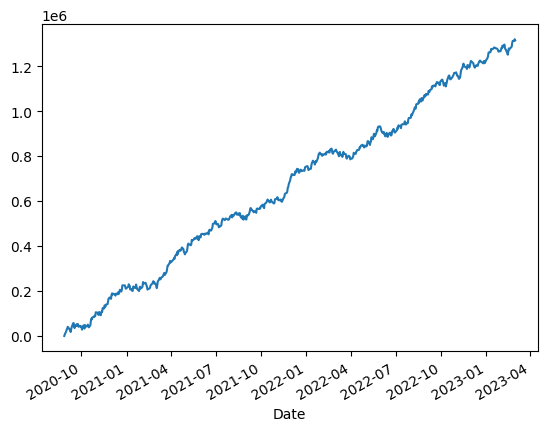

In [28]:
mts_is.data[best_is_pnl].diff().sum(axis = 1).cumsum().plot()

<Axes: xlabel='Date'>

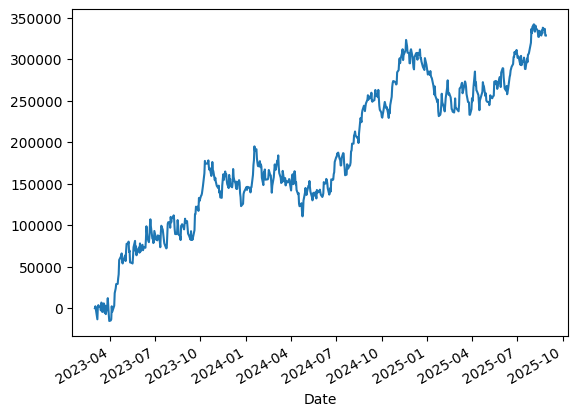

In [27]:
mts_os.data[best_is_pnl].diff().sum(axis = 1).cumsum().plot()

In [ ]:
weights = {
    "WIN$N_WSP$N_RSI_RSI_RATIO_8431441702667994264": 1,
"WIN$N_WSP$N_RSI_RSI_RATIO_7066963457615126378": 1,
"WIN$N_WSP$N_MOMENTUM_MOMENTUM_RATIO_15745913838704788129": 1,
"WIN$N_WIN$N_RSI_RETURNS_RATIO_2147226274691018798": 1,
"WIN$N_WIN$N_RETURNS_PRICE_MAMA_DISTANCE_SPREAD_15541506442948395777": 1,
"WIN$N_WIN$N_RETURNS_MAMA_DISTANCE_SPREAD_13287722170295900052": 1,
"WIN$N_WIN$N_PRICES_RSI_RATIO_11616511845534960856": 1,
"WIN$N_WIN$N_MOMENTUM_RETURNS_RATIO_4941167865114217978": 1,
"WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_3715281047835224916": 1,
"WIN$N_WIN$N_MOMENTUM_PRICE_MAMA_DISTANCE_SPREAD_11721238061880443942": 1,
"WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_16975149508379497472": 1,
"WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_4503286728177737452": 1,
"WIN$N_WDO$N_RSI_RSI_RATIO_14399917438557488223": 1,
"WIN$N_WDO$N_RSI_RSI_RATIO_12548509201202940488": 1,
"WIN$N_WDO$N_PRICES_PRICES_RATIO_18112357166312811078": 1,
"WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_15652472584227467281": 1,
"WIN$N_WDO$N_MOMENTUM_MOMENTUM_RATIO_545334067150811836": 1,
"WIN$N_WDO$N_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_1415433955947169891": 1,
"WIN$N_BOVA11_RETURNS_RETURNS_SPREAD_13958889995319245783": 1,
"WIN$N_BOVA11_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_10363284119758261605": 1,}

In [19]:
t = mts.portfolio(weights=weights, percentage = False, shares = True) * 2

array([[<Axes: title={'center': 'portfolio'}>]], dtype=object)

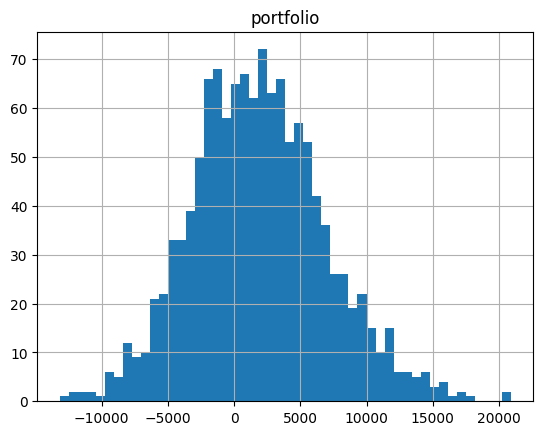

In [24]:
t.returns(method='absolute').data.hist(bins=50)

In [59]:
for key in search_space[3]['best_individual'].get_weights().keys():
    import shutil
    import os

    # Get the source and destination paths
    source_path = os.path.join(data_path, '..', 'parameters', f'{key}.set')
    dest_path = os.path.join(data_path, '..', 'prod')

    # Create destination directory if it doesn't exist
    os.makedirs(dest_path, exist_ok=True)

    # Copy the file
    try:
        shutil.copy2(source_path, dest_path)
        print(f"✅ Copied {key}.set to prod directory")
    except FileNotFoundError:
        print(f"❌ File {key}.set not found in parameters directory")
    except Exception as e:
        print(f"❌ Error copying {key}.set: {e}")

✅ Copied WIN$N_BOVA11_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_10363284119758261605.set to prod directory
✅ Copied WIN$N_BOVA11_RETURNS_RETURNS_SPREAD_13958889995319245783.set to prod directory
✅ Copied WIN$N_WDO$N_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_1415433955947169891.set to prod directory
✅ Copied WIN$N_WDO$N_MOMENTUM_MOMENTUM_RATIO_545334067150811836.set to prod directory
✅ Copied WIN$N_WDO$N_PRICES_PRICES_RATIO_18112357166312811078.set to prod directory
✅ Copied WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_15652472584227467281.set to prod directory
✅ Copied WIN$N_WDO$N_RSI_RSI_RATIO_12548509201202940488.set to prod directory
✅ Copied WIN$N_WDO$N_RSI_RSI_RATIO_14399917438557488223.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_16975149508379497472.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_MAMA_DISTANCE_SPREAD_4503286728177737452.set to prod directory
✅ Copied WIN$N_WIN$N_MOMENTUM_PRICES_SINGLE_3715281047835224916.set to prod directory
✅ Co

In [ ]:
(best_strategy.data * 2)

,portfolio
Date,
2020-08-27,-102.0
2020-08-28,1536.0
2020-08-31,1530.0
2020-09-01,17216.0
2020-09-02,26188.0
...,...
2025-08-22,2326206.0
2025-08-25,2325650.0
2025-08-26,2329900.0
